In [1]:
import torch
import torchmetrics
import torch.nn as nn
import matplotlib.pyplot as plt

plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [2]:
from pathlib import Path
import pandas as pd
import tarfile
import urllib.request

def download_and_extract_ridership_data():
    tarball_path = Path("datasets/ridership.tgz")

    if not tarball_path.is_file():
        Path("datasets").mkdir(parents=True, exist_ok=True)
        url = "https://github.com/ageron/data/raw/main/ridership.tgz"
        urllib.request.urlretrieve(url, tarball_path)
        with tarfile.open(tarball_path) as ridership_tarball:
            ridership_tarball.extractall(path="datasets", filter="data")
            
download_and_extract_ridership_data()

In [3]:
from pathlib import Path

path = Path("datasets/ridership/CTA_-_Ridership_-_Daily_Boarding_Totals.csv")
df = pd.read_csv(path, parse_dates=["service_date"])
df.columns = ["date", "day_type", "bus", "rail", "total"]
df = df.sort_values("date").set_index("date")
df = df.drop("total", axis=1)
df = df.drop_duplicates()

In [4]:
df.head()

,day_type,bus,rail
date,,,
2001-01-01,U,297192,126455
2001-01-02,W,780827,501952
2001-01-03,W,824923,536432
2001-01-04,W,870021,550011
2001-01-05,W,890426,557917


<Axes: xlabel='date'>

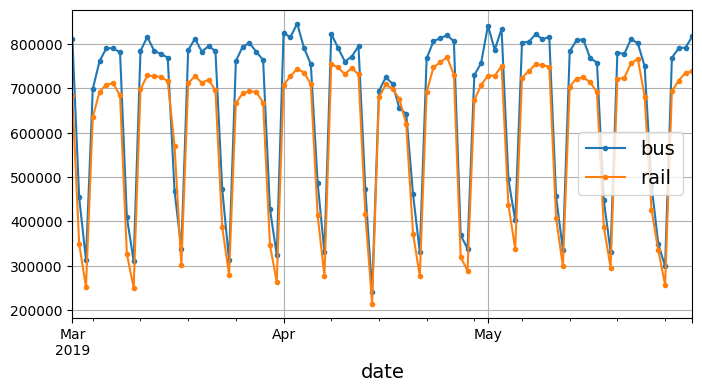

In [5]:
import matplotlib.pyplot as plt

df["2019-03":"2019-05"].plot(grid=True, marker=".", figsize=(8,4))

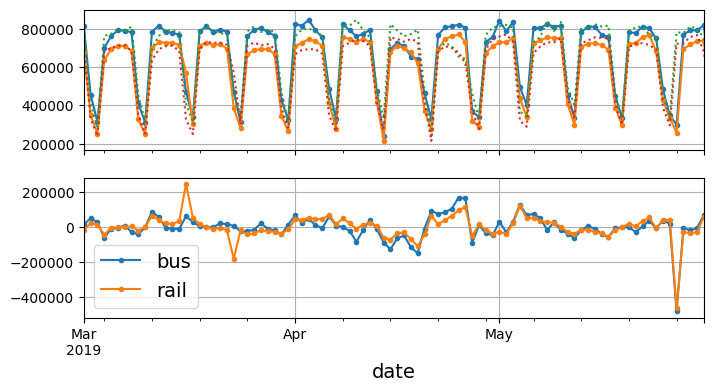

In [6]:
diff_7 = df[["bus", "rail"]].diff(7)["2019-03":"2019-05"]

fig,axs = plt.subplots(2,1,sharex=True, figsize=(8,4))
df.plot(ax=axs[0], legend=False, grid=True, marker=".") # original time series
df.shift(7).plot(ax=axs[0], grid=True, legend=False, linestyle=":") #lagged time series
diff_7.plot(ax=axs[1], grid=True, marker=".") #7 day difference time series

axs[0].set_ylim([170_000, 900_000])

plt.show()


In [7]:
list(df.loc["2019-05-25":"2019-05-27"]["day_type"])

['A', 'U', 'U']

In [8]:
diff_7.abs().mean()

bus     43915.608696
rail    42143.271739
dtype: float64

In [9]:
targets = df[["bus", "rail"]]["2019-03":"2019-05"]
(diff_7 / targets).abs().mean()


bus     0.082938
rail    0.089948
dtype: float64

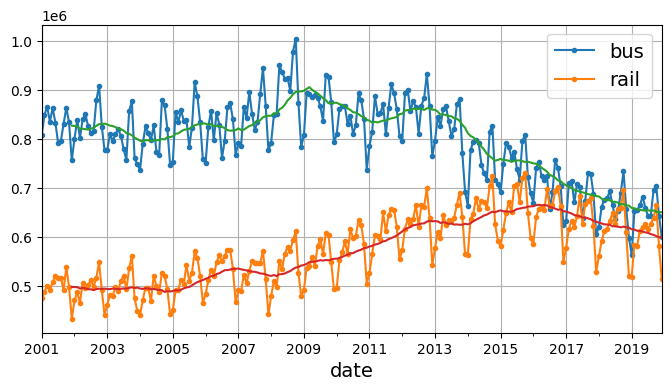

In [10]:
period = slice("2001", "2019")
# period
df_monthly = df.select_dtypes(include="number").resample("ME").mean()
rolling_average_12_months = df_monthly.loc[period].rolling(window=12).mean()

fig, ax = plt.subplots(figsize=(8,4))
df_monthly[period].plot(ax=ax, marker=".")
rolling_average_12_months.plot(ax=ax, grid=True, legend = False)
plt.show()

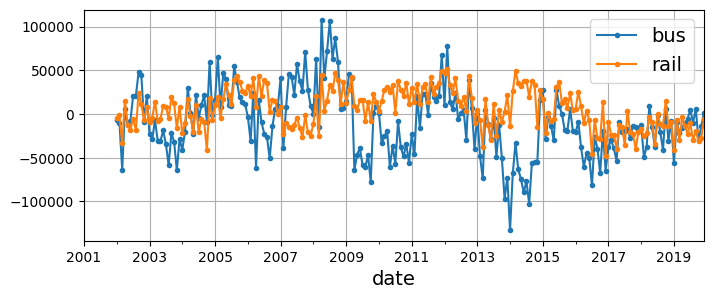

In [11]:
df_monthly.diff(12)[period].plot(grid=True, marker=".", figsize=(8,3))
plt.show()

### The ARMA Model Family

In [12]:
from statsmodels.tsa.arima.model import ARIMA

origin, today = "2019-01-01", "2019-05-31"
rail_series = df.loc[origin:today]["rail"].asfreq("D")
model = ARIMA(rail_series,
              order=(1,0,0),
              seasonal_order=(0,1,1,7))

model = model.fit()
y_pred = model.forecast()
y_pred

2019-06-01    427758.626421
Freq: D, dtype: float64

In [13]:
df['rail'].loc["2019-06-01"]

np.int64(379044)

In [14]:
df["rail"].loc["2019-05-25"]

np.int64(426932)

In [15]:
origin, start_date, end_date = "2019-01-01", "2019-03-01", "2019-05-31"
time_period = pd.date_range(start_date, end_date)
rail_series = df.loc[origin:end_date]["rail"].asfreq("D")
y_preds = []

for today in time_period.shift(-1):
    model = ARIMA(rail_series[origin:today], 
                  order=(1,0,0),
                  seasonal_order=(0,1,1,7))
    model = model.fit()
    y_pred = model.forecast().iloc[0]
    y_preds.append(y_pred)

y_preds = pd.Series(y_preds, index=time_period)
mae = (y_preds - rail_series[time_period]).abs().mean()
    


In [16]:
mae

np.float64(32040.720094289627)

/tmp/ipykernel_5666/1576515880.py:5: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  ax.plot(y_preds, marker=".", color="r", label="SARIMA Forecasts")


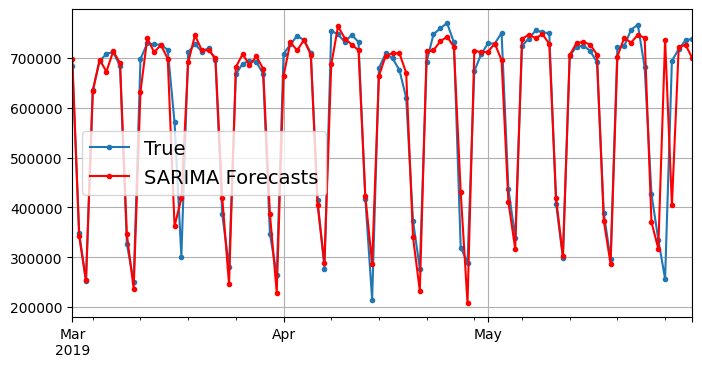

In [17]:
#displays the sarima forecasts

fig, ax = plt.subplots(figsize=(8,4))
rail_series.loc[time_period].plot(label="True", ax=ax, marker=".", grid=True)
ax.plot(y_preds, marker=".", color="r", label="SARIMA Forecasts")
plt.legend()
plt.show()

### Preparing the Data for machine learning models

In [18]:
class TimeSeriesDataset(torch.utils.data.Dataset):
    def __init__(self, series, window_length) -> None:
        super().__init__()
        self.series = series
        self.window_length = window_length

    def __len__(self):
        return max(0, len(self.series) - self.window_length)
    
    def __getitem__(self, index):
        if index >= len(self):
            raise IndexError("dataset index out of range")
        end = index + self.window_length
        window = self.series[index:end]
        target = self.series[end]
        return window, target
    

In [19]:
my_series = torch.tensor([[0], [1], [2], [3], [4], [5]])
my_dataset = TimeSeriesDataset(my_series, 3)
for window, target in my_dataset:
    print(f"Window:{window}, target: {target}")


Window:tensor([[0],
        [1],
        [2]]), target: tensor([3])
Window:tensor([[1],
        [2],
        [3]]), target: tensor([4])
Window:tensor([[2],
        [3],
        [4]]), target: tensor([5])


In [20]:
from torch.utils.data import DataLoader

torch.manual_seed(0)
my_loader = DataLoader(my_dataset, batch_size=2, shuffle=True)
for X,y in my_loader:
    print(f"X:{X}, y:{y}")

X:tensor([[[0],
         [1],
         [2]],

        [[2],
         [3],
         [4]]]), y:tensor([[3],
        [5]])
X:tensor([[[1],
         [2],
         [3]]]), y:tensor([[4]])


In [21]:
rail_train = torch.FloatTensor(df[["rail"]]["2016-01":"2018-12"].values / 1e6)
rail_valid = torch.FloatTensor(df[["rail"]]["2019-01":"2019-05"].values / 1e6)
rail_test = torch.FloatTensor(df[["rail"]]["2019-06":].values / 1e6)

In [22]:
window_length = 56

train_set = TimeSeriesDataset(rail_train, window_length)
train_loader = DataLoader(train_set, batch_size=32, shuffle=True)

valid_set = TimeSeriesDataset(rail_valid, window_length)
valid_loader = DataLoader(valid_set, batch_size=32)

test_set = TimeSeriesDataset(rail_test, window_length)
test_loader = DataLoader(test_set, batch_size=32)

### Forecasting using a Linear Model

In [23]:
import torchmetrics

def evaluate_tm(model, data_loader, metric):
    model.eval()
    metric.reset()

    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            # print(f"pred shape-{y_pred.shape}, input shape-{y_batch.shape}")

            if torch.isnan(y_pred).any():
                print("Warning! NaN detected in model predictions during validation!")

            metric.update(y_pred, y_batch)
    return metric.compute()

def train(model, optimizer, loss_fn, train_metric, valid_metric, train_loader, valid_loader, n_epochs, patience=10, factor=0.1):
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", patience=patience, factor=factor
    )
    history = {
        "train_losses":[],
        "train_metrics":[],
        "valid_metrics":[]
    }
    
    for epoch in range(n_epochs):
        total_loss = 0.0
        train_metric.reset()
        model.train()

        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            loss = loss_fn(y_pred, y_batch)
            total_loss += loss.item()
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            train_metric.update(y_pred, y_batch)
        history["train_losses"].append(total_loss/len(train_loader))
        history["train_metrics"].append(train_metric.compute().item())
        val_metric = evaluate_tm(model, valid_loader, valid_metric).item()
        history["valid_metrics"].append(val_metric)
        scheduler.step(val_metric)
        print(f"Epoch {epoch + 1}/{n_epochs}, "
              f"train loss: {history['train_losses'][-1]:.4f}, "
              f"train metric: {history['train_metrics'][-1]:.4f}, "
              f"valid metric: {history['valid_metrics'][-1]:.4f}")
    return history



In [24]:
X, y = next(iter(train_loader))
print(f"{X.shape}, {y.shape}")

torch.Size([32, 56, 1]), torch.Size([32, 1])


In [25]:
torch.manual_seed(42)
model = nn.Sequential(nn.Flatten(),
                      nn.Linear(window_length, 1)).to(device)
loss_fn = nn.HuberLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.003, momentum=0.9)
train_metric = torchmetrics.MeanAbsoluteError().to(device)
valid_metric = torchmetrics.MeanAbsoluteError().to(device)

history=train(model, optimizer, loss_fn, train_metric, valid_metric, train_loader, valid_loader, 50)
# history

Epoch 1/50, train loss: 0.0154, train metric: 0.1458, valid metric: 0.1235
Epoch 2/50, train loss: 0.0100, train metric: 0.1117, valid metric: 0.0996
Epoch 3/50, train loss: 0.0075, train metric: 0.0933, valid metric: 0.0795
Epoch 4/50, train loss: 0.0063, train metric: 0.0816, valid metric: 0.0668
Epoch 5/50, train loss: 0.0056, train metric: 0.0741, valid metric: 0.0609
Epoch 6/50, train loss: 0.0053, train metric: 0.0697, valid metric: 0.0550
Epoch 7/50, train loss: 0.0049, train metric: 0.0663, valid metric: 0.0545
Epoch 8/50, train loss: 0.0047, train metric: 0.0636, valid metric: 0.0493
Epoch 9/50, train loss: 0.0045, train metric: 0.0617, valid metric: 0.0457
Epoch 10/50, train loss: 0.0045, train metric: 0.0615, valid metric: 0.0437
Epoch 11/50, train loss: 0.0043, train metric: 0.0586, valid metric: 0.0453
Epoch 12/50, train loss: 0.0042, train metric: 0.0577, valid metric: 0.0420
Epoch 13/50, train loss: 0.0042, train metric: 0.0576, valid metric: 0.0403
Epoch 14/50, train lo

In [26]:
evaluate_tm(model, valid_loader, valid_metric) * 1e6

tensor(37725.7188, device='cuda:0')

### Forecasting using a simple RNN

In [27]:
class SimpleRnnModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        self.hidden_size = hidden_size
        self.memory_cell = nn.Sequential(
            nn.Linear(input_size+hidden_size, hidden_size),
            nn.Tanh()
        )
        self.output = nn.Linear(hidden_size, output_size)

    def forward(self, X):
        batch_size, window_length, dimensionality = X.shape
        X_time_first = X.transpose(0,1)
        H = torch.zeros(batch_size, self.hidden_size, device=X.device)
        for X_t in X_time_first:
            XH = torch.cat((X_t, H), dim=1)
            H = self.memory_cell(XH)
        return self.output(H)

torch.manual_seed(42)
model = SimpleRnnModel(input_size=1, hidden_size=32, output_size=1).to(device)


In [28]:
def fit_and_evaluate(model, train_loader,valid_loader, lr, n_epochs=50,
                     patience=20, factor=0.1):
    loss_fn = nn.HuberLoss()
    optimizer=torch.optim.SGD(model.parameters(), lr=lr, momentum=0.95,)
    train_metric = torchmetrics.MeanAbsoluteError().to(device)
    valid_metric = torchmetrics.MeanAbsoluteError().to(device)
    history=train(model, optimizer, loss_fn, train_metric, valid_metric, 
                  train_loader, valid_loader, n_epochs, patience, factor)
    return min(history["valid_metrics"]) * 1e6

In [29]:
torch.manual_seed(42)
univar_model = SimpleRnnModel(input_size=1, hidden_size=32, output_size=1).to(device)
fit_and_evaluate(univar_model, train_loader, valid_loader, 0.05, 50)

Epoch 1/50, train loss: 0.0523, train metric: 0.2600, valid metric: 0.2126
Epoch 2/50, train loss: 0.0174, train metric: 0.1542, valid metric: 0.1167
Epoch 3/50, train loss: 0.0135, train metric: 0.1421, valid metric: 0.1166
Epoch 4/50, train loss: 0.0106, train metric: 0.1212, valid metric: 0.1054
Epoch 5/50, train loss: 0.0075, train metric: 0.0968, valid metric: 0.0914
Epoch 6/50, train loss: 0.0060, train metric: 0.0831, valid metric: 0.0759
Epoch 7/50, train loss: 0.0055, train metric: 0.0776, valid metric: 0.0749
Epoch 8/50, train loss: 0.0051, train metric: 0.0748, valid metric: 0.0683
Epoch 9/50, train loss: 0.0047, train metric: 0.0710, valid metric: 0.0615
Epoch 10/50, train loss: 0.0047, train metric: 0.0706, valid metric: 0.0629
Epoch 11/50, train loss: 0.0047, train metric: 0.0699, valid metric: 0.0652
Epoch 12/50, train loss: 0.0046, train metric: 0.0696, valid metric: 0.0576
Epoch 13/50, train loss: 0.0045, train metric: 0.0689, valid metric: 0.0733
Epoch 14/50, train lo

30511.01043820381

In [30]:
class SimpleRnnModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        self.rnn = nn.RNN(input_size, hidden_size, batch_first=True)
        self.output = nn.Linear(hidden_size, output_size)

    def forward(self, X):
        outputs, last_state = self.rnn(X)
        return self.output(outputs[:,-1,:])


In [31]:
torch.manual_seed(42)
univar_model = SimpleRnnModel(1,32,1).to(device)
fit_and_evaluate(univar_model, train_loader, valid_loader, 0.05,50)

Epoch 1/50, train loss: 0.0487, train metric: 0.2535, valid metric: 0.1329
Epoch 2/50, train loss: 0.0181, train metric: 0.1523, valid metric: 0.1268
Epoch 3/50, train loss: 0.0137, train metric: 0.1459, valid metric: 0.1377
Epoch 4/50, train loss: 0.0122, train metric: 0.1348, valid metric: 0.1184
Epoch 5/50, train loss: 0.0115, train metric: 0.1279, valid metric: 0.1255
Epoch 6/50, train loss: 0.0105, train metric: 0.1231, valid metric: 0.1130
Epoch 7/50, train loss: 0.0090, train metric: 0.1127, valid metric: 0.1018
Epoch 8/50, train loss: 0.0064, train metric: 0.0885, valid metric: 0.0781
Epoch 9/50, train loss: 0.0055, train metric: 0.0792, valid metric: 0.0682
Epoch 10/50, train loss: 0.0048, train metric: 0.0727, valid metric: 0.0662
Epoch 11/50, train loss: 0.0044, train metric: 0.0683, valid metric: 0.0585
Epoch 12/50, train loss: 0.0043, train metric: 0.0675, valid metric: 0.0618
Epoch 13/50, train loss: 0.0043, train metric: 0.0662, valid metric: 0.0691
Epoch 14/50, train lo

30659.610405564308

#### Deep RNNs

In [32]:
class DeepRnnModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, num_layers):
        super().__init__()
        self.rnn = nn.RNN(input_size, hidden_size, num_layers, batch_first=True)
        self.output = nn.Linear(hidden_size, output_size)

    def forward(self, X):
        outputs, last_state = self.rnn(X)
        return self.output(outputs[:,-1,:])


torch.manual_seed(42)
deep_model = DeepRnnModel(
    input_size=1, hidden_size=32, output_size=1,num_layers=3
).to(device)
fit_and_evaluate(deep_model, train_loader, valid_loader, lr=0.1, n_epochs=50)

Epoch 1/50, train loss: 0.0565, train metric: 0.2593, valid metric: 0.1260
Epoch 2/50, train loss: 0.0098, train metric: 0.1103, valid metric: 0.0770
Epoch 3/50, train loss: 0.0078, train metric: 0.0995, valid metric: 0.0863
Epoch 4/50, train loss: 0.0062, train metric: 0.0832, valid metric: 0.0648
Epoch 5/50, train loss: 0.0048, train metric: 0.0661, valid metric: 0.0534
Epoch 6/50, train loss: 0.0045, train metric: 0.0622, valid metric: 0.0698
Epoch 7/50, train loss: 0.0042, train metric: 0.0628, valid metric: 0.0424
Epoch 8/50, train loss: 0.0038, train metric: 0.0592, valid metric: 0.0468
Epoch 9/50, train loss: 0.0043, train metric: 0.0663, valid metric: 0.0447
Epoch 10/50, train loss: 0.0038, train metric: 0.0593, valid metric: 0.0780
Epoch 11/50, train loss: 0.0040, train metric: 0.0623, valid metric: 0.0364
Epoch 12/50, train loss: 0.0041, train metric: 0.0660, valid metric: 0.0752
Epoch 13/50, train loss: 0.0048, train metric: 0.0705, valid metric: 0.0444
Epoch 14/50, train lo

29814.04773890972

### Forecasting Multivariate Time Series

In [33]:
df_multivar = df[["rail", "bus"]] / 1e6
df_multivar["next_day_type"] = df["day_type"].shift(-1)
df_multivar = pd.get_dummies(df_multivar, dtype=float)

In [34]:
df_multivar.tail()

,rail,bus,next_day_type_A,next_day_type_U,next_day_type_W
date,,,,,
2021-11-26,0.189694,0.257700,1.0,0.0,0.0
2021-11-27,0.187065,0.237839,0.0,1.0,0.0
2021-11-28,0.147830,0.184817,0.0,0.0,1.0
2021-11-29,0.276090,0.421322,0.0,0.0,1.0
2021-11-30,0.302349,0.450230,0.0,0.0,0.0


In [35]:
mutlivar_train = torch.FloatTensor(df_multivar["2016-01":"2018-12"].values)
mutlivar_valid = torch.FloatTensor(df_multivar["2019-01":"2019-05"].values)
multivar_test = torch.FloatTensor(df_multivar["2019-06":].values)

In [36]:
class MultivarTimeSeriesDataset(TimeSeriesDataset):
    def __getitem__(self, index):
        window, target =  super().__getitem__(index)
        return window, target[:1] 
    '''we want to return the first column (rail) as target but we dont use
    target[0] as the shape will be () but we want (1,)'''

In [37]:
window_length=56

mutlivar_train_set = MultivarTimeSeriesDataset(mutlivar_train, window_length)
multivar_train_loader = DataLoader(mutlivar_train_set, batch_size=32, shuffle=True)

multivar_valid_set = MultivarTimeSeriesDataset(mutlivar_valid, window_length)
multivar_valid_loader = DataLoader(multivar_valid_set, 32)

multivar_test_set = MultivarTimeSeriesDataset(multivar_test, window_length)
multivar_test_loader = DataLoader(multivar_test_set, 32)

In [38]:
(next(iter(multivar_train_loader)))[0].shape

torch.Size([32, 56, 5])

In [39]:
torch.manual_seed(42)
multivar_model = SimpleRnnModel(5,32,1).to(device)

fit_and_evaluate(multivar_model, multivar_train_loader, multivar_valid_loader,0.05,50)

Epoch 1/50, train loss: 0.0652, train metric: 0.2960, valid metric: 0.0527
Epoch 2/50, train loss: 0.0076, train metric: 0.1007, valid metric: 0.0425
Epoch 3/50, train loss: 0.0028, train metric: 0.0558, valid metric: 0.0313
Epoch 4/50, train loss: 0.0018, train metric: 0.0410, valid metric: 0.0359
Epoch 5/50, train loss: 0.0017, train metric: 0.0383, valid metric: 0.0381
Epoch 6/50, train loss: 0.0015, train metric: 0.0368, valid metric: 0.0365
Epoch 7/50, train loss: 0.0014, train metric: 0.0356, valid metric: 0.0320
Epoch 8/50, train loss: 0.0014, train metric: 0.0364, valid metric: 0.0247
Epoch 9/50, train loss: 0.0014, train metric: 0.0356, valid metric: 0.0257
Epoch 10/50, train loss: 0.0015, train metric: 0.0380, valid metric: 0.0308
Epoch 11/50, train loss: 0.0013, train metric: 0.0339, valid metric: 0.0332
Epoch 12/50, train loss: 0.0012, train metric: 0.0328, valid metric: 0.0267
Epoch 13/50, train loss: 0.0012, train metric: 0.0332, valid metric: 0.0402
Epoch 14/50, train lo

23224.53446686268

In [40]:
'''evalutates the naive forecasts for bus'''
bus_naive = df_multivar["2019-01":"2019-05"]["bus"].shift(7)[window_length:]
bus_target = df_multivar["2019-01":"2019-05"]["bus"][window_length:]
(bus_target-bus_naive).abs().mean() * 1e6

np.float64(43441.63157894738)

### Forecasting Several times ahead

In [41]:
univar_model.eval()
n_steps = 14
with torch.no_grad():
    #dim=0 as we add a batch dimension in the 1st index
    X=rail_valid[:window_length].unsqueeze(dim=0).to(device)
    for step_ahead in range(n_steps):
        y_pred = univar_model(X)
        #dim=1 in usqueeze as we want to 
        X = torch.cat([X, y_pred.unsqueeze(dim=1)], dim=1)
    Y_pred = X[0,-n_steps:, 0]
Y_pred * 1e6

tensor([719770.5625, 731138.7500, 721996.1250, 715643.3750, 415405.6875,
        315855.3750, 677661.5625, 732854.1250, 737591.3750, 729897.1875,
        725031.2500, 427196.8438, 326606.3750, 682157.1875], device='cuda:0')

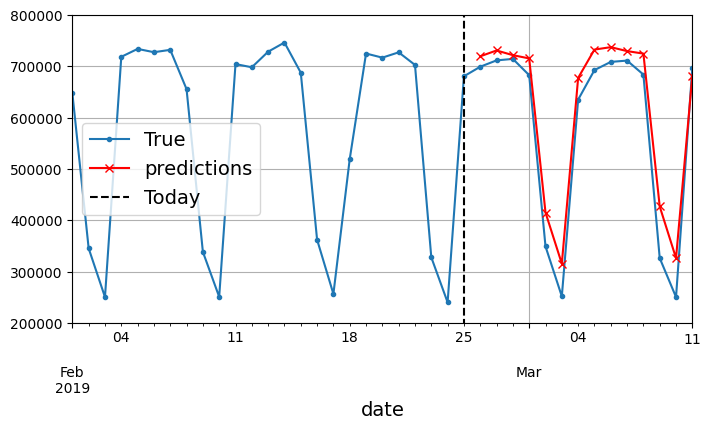

In [42]:
Y_pred_s = pd.Series(Y_pred.cpu() * 1e6, index=pd.date_range("2019-02-26","2019-03-11"))
fig,ax = plt.subplots(figsize=(8,4))

df["2019-02-01":"2019-03-11"]['rail'].plot(label="True", ax=ax, grid=True, marker=".")
Y_pred_s.plot(label="predictions", ax=ax, color="r", marker="x",grid=True)
ax.vlines("2019-02-25", 0, 1e6, color="k", linestyle="--", label="Today")
ax.set_ylim([200_000, 800_000])
plt.legend(loc="center left")

plt.show()

In [43]:
class ForecastAheadDataset(TimeSeriesDataset):
    def __init__(self, series, window_length, look_ahead):
        # super().__init__()
        self.series = series
        self.window_length = window_length
        self.look_ahead = look_ahead


    def __len__(self):
        return len(self.series) - self.window_length - self.look_ahead + 1
    def __getitem__(self, idx):
        end = idx + self.window_length
        window = self.series[idx:end]
        target = self.series[end: end + self.look_ahead, 0] # 0 for rail ridership
        return window, target

Notice that to output a vector (in this case 14 values), the model is kept the same,just the dataset which sets the target has been changed, surely when we create the model (a simple rnn), the output_size arguement will be set to 14 to match the target size.

In [44]:
window_length = 56
look_ahead = 14
ahead_train_set = ForecastAheadDataset(mutlivar_train, window_length, look_ahead)
ahead_train_loader = DataLoader(ahead_train_set, 32,True)

ahead_valid_set=ForecastAheadDataset(mutlivar_valid, window_length, look_ahead)
ahead_valid_loader = DataLoader(ahead_valid_set, 32)

ahead_test_set = ForecastAheadDataset(multivar_test, window_length, look_ahead)
ahead_test_loader = DataLoader(ahead_test_set, 32)

In [45]:
torch.manual_seed(42)
ahead_model = SimpleRnnModel(input_size=5, hidden_size=32, output_size=14).to(device)
fit_and_evaluate(ahead_model, ahead_train_loader, ahead_valid_loader, 0.05,50)

Epoch 1/50, train loss: 0.0725, train metric: 0.3051, valid metric: 0.1730
Epoch 2/50, train loss: 0.0164, train metric: 0.1480, valid metric: 0.1142
Epoch 3/50, train loss: 0.0099, train metric: 0.1133, valid metric: 0.0975
Epoch 4/50, train loss: 0.0076, train metric: 0.0946, valid metric: 0.0832
Epoch 5/50, train loss: 0.0066, train metric: 0.0846, valid metric: 0.0749
Epoch 6/50, train loss: 0.0060, train metric: 0.0783, valid metric: 0.0651
Epoch 7/50, train loss: 0.0053, train metric: 0.0728, valid metric: 0.0600
Epoch 8/50, train loss: 0.0052, train metric: 0.0685, valid metric: 0.0554
Epoch 9/50, train loss: 0.0047, train metric: 0.0663, valid metric: 0.0546
Epoch 10/50, train loss: 0.0044, train metric: 0.0633, valid metric: 0.0506
Epoch 11/50, train loss: 0.0043, train metric: 0.0619, valid metric: 0.0489
Epoch 12/50, train loss: 0.0042, train metric: 0.0604, valid metric: 0.0471
Epoch 13/50, train loss: 0.0042, train metric: 0.0598, valid metric: 0.0498
Epoch 14/50, train lo

32945.73351740837

### Forecasting using a Sequence to Sequence model

In [ ]:
class Seq2SeqDataset(ForecastAheadDataset):
    def __getitem__(self, idx):
        end = idx + self.window_length
        window = self.series[idx:end]
        target_period = self.series[idx + 1: end + self.look_ahead, 0]
        target = target_period.unfold(dimension=0,size=self.look_ahead, step=1)
        return window, target


In [47]:
window_length=56
seq_train_set = Seq2SeqDataset(mutlivar_train, window_length, 14)
seq_train_loader = DataLoader(seq_train_set, 32, True)

seq_valid_set = Seq2SeqDataset(mutlivar_valid, window_length, 14)
seq_valid_loader = DataLoader(seq_valid_set, batch_size=32)

seq_test_set = Seq2SeqDataset(multivar_test, window_length, 14)
seq_test_loader = DataLoader(seq_test_set, batch_size=32)

In [48]:
class Seq2RnnModel(SimpleRnnModel):
    def forward(self, X):
        outputs, last_state = self.rnn(X)
        return self.output(outputs)

In [49]:
torch.manual_seed(42)
seq_model = Seq2RnnModel(input_size=5, hidden_size=32, output_size=14).to(device)
fit_and_evaluate(seq_model, seq_train_loader, seq_valid_loader, 1.0, 65, 5, 0.5)

Epoch 1/65, train loss: 0.0332, train metric: 0.1934, valid metric: 0.1210
Epoch 2/65, train loss: 0.0084, train metric: 0.0975, valid metric: 0.0756
Epoch 3/65, train loss: 0.0050, train metric: 0.0696, valid metric: 0.0662
Epoch 4/65, train loss: 0.0042, train metric: 0.0600, valid metric: 0.0493
Epoch 5/65, train loss: 0.0043, train metric: 0.0631, valid metric: 0.1053
Epoch 6/65, train loss: 0.0040, train metric: 0.0569, valid metric: 0.0545
Epoch 7/65, train loss: 0.0035, train metric: 0.0524, valid metric: 0.0656
Epoch 8/65, train loss: 0.0036, train metric: 0.0519, valid metric: 0.0557
Epoch 9/65, train loss: 0.0034, train metric: 0.0508, valid metric: 0.0485
Epoch 10/65, train loss: 0.0035, train metric: 0.0535, valid metric: 0.0552
Epoch 11/65, train loss: 0.0034, train metric: 0.0507, valid metric: 0.0536
Epoch 12/65, train loss: 0.0035, train metric: 0.0543, valid metric: 0.0698
Epoch 13/65, train loss: 0.0034, train metric: 0.0518, valid metric: 0.0642
Epoch 14/65, train lo

46197.835355997086

In [50]:
seq_model.eval()
with torch.no_grad():
    some_window = mutlivar_valid[:window_length]
    X = some_window.unsqueeze(dim=0)
    Y_preds = seq_model(X.to(device))
    Y_pred = Y_preds[:, -1]

In [54]:
with torch.no_grad():
    X = mutlivar_valid.unsqueeze(dim=0).to(device)
    Y_preds_valid = seq_model(X).cpu()

for ahead in range(1, 14+1):
    y_preds = Y_preds_valid[0,window_length:-ahead, ahead-1]
    y_true = rail_valid[window_length+ahead:, 0]
    mae = (y_preds - y_true).abs().mean() * 1e6
    print(f"MAE for +{ahead}:\t{mae: ,.0f}")

MAE for +1:	 23,414
MAE for +2:	 35,228
MAE for +3:	 37,064
MAE for +4:	 39,247
MAE for +5:	 39,227
MAE for +6:	 39,948
MAE for +7:	 39,362
MAE for +8:	 39,947
MAE for +9:	 40,286
MAE for +10:	 39,906
MAE for +11:	 39,915
MAE for +12:	 38,418
MAE for +13:	 36,639
MAE for +14:	 35,238
